In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras.backend as K

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256,256,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
base_dataset = "/content/drive/MyDrive/Data"

In [5]:
img_size = (256, 256)
batch_size = 12

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    base_dataset,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 1748 images belonging to 2 classes.
Found 436 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'BENIGN': 0, 'MALIGNANT': 1}


In [7]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.8927477017364658), 1: np.float64(1.1365409622886866)}


In [8]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [14]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 1067s 7s/step - accuracy: 0.5521 - loss: 0.8455 - val_accuracy: 0.5092 - val_loss: 0.6998 - learning_rate: 0.0010
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.5738 - loss: 0.7423 - val_accuracy: 0.5596 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 138s 948ms/step - accuracy: 0.5704 - loss: 0.7386 - val_accuracy: 0.5252 - val_loss: 0.7082 - learning_rate: 0.0010
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.5938 - loss: 0.6979
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
146/146 ━━━━━━━━━━━━━━━━━━━━ 131s 901ms/step - accuracy: 0.5927 - loss: 0.7053 - val_accuracy: 0.4404 - val_loss: 0.8962 - learning_rate: 0.0010
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 136s 927ms/step - accuracy: 0.5950 - loss: 0.6938 - val_accuracy: 0.4404 - val_loss: 1.0178 - learning_rate: 5.0000e-04
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.5

In [16]:
model.save("/content/drive/MyDrive/CNN_Custom.h5")
print("Model saved successfully")

Model saved successfully


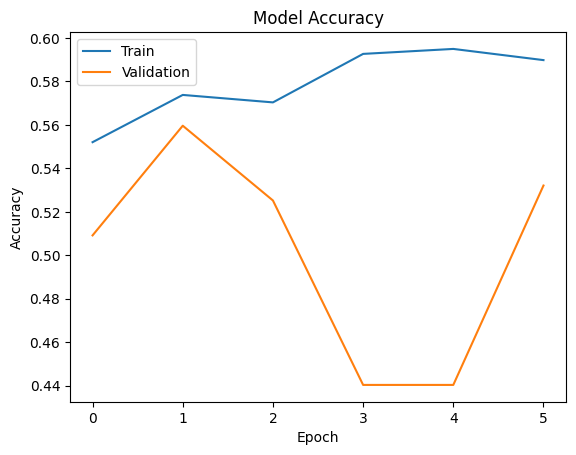

In [17]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

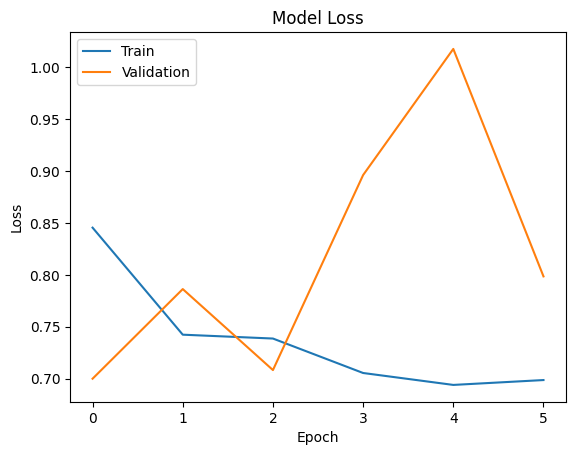

In [18]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [21]:
val_generator.reset()
pred = model.predict(val_generator)
pred_classes = (pred > 0.5).astype(int)

true_classes = val_generator.classes

print(confusion_matrix(true_classes, pred_classes))
print(classification_report(true_classes, pred_classes))

roc = roc_auc_score(true_classes, pred)
print("ROC AUC Score:", roc)

37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 751ms/step
[[162  82]
 [132  60]]
              precision    recall  f1-score   support

           0       0.55      0.66      0.60       244
           1       0.42      0.31      0.36       192

    accuracy                           0.51       436
   macro avg       0.49      0.49      0.48       436
weighted avg       0.49      0.51      0.50       436

ROC AUC Score: 0.46821635928961747


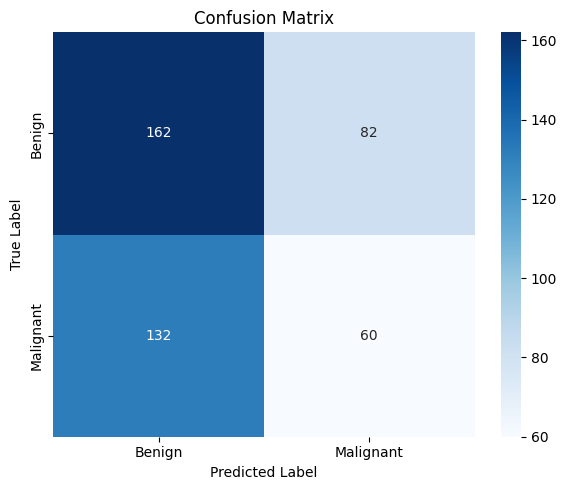

In [22]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
K.clear_session()